In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

In [2]:
analyzer = SentimentIntensityAnalyzer()

In [3]:
reviews = {
    "review": [
        "The product is excellent and works perfectly.",
        "I am very happy with this purchase.",
        "Amazing quality and very useful product.",
        "The product exceeded my expectations.",
        "Very good product and fast delivery.",
        "I really love this product.",
        "The quality is great and worth the money.",
        "Excellent product, I would recommend it.",
        "The product is okay.",
        "It is an average product.",
        "The product is neither good nor bad.",
        "It works as expected.",
        "The quality is poor.",
        "I am disappointed with this product.",
        "The product stopped working after a few days.",
        "Very bad quality.",
        "I regret buying this product.",
        "The product is not worth the money.",
        "The delivery was late and the product was damaged.",
        "I did not like this product."
    ]
}

df = pd.DataFrame(reviews)

df.head()

,review
0,The product is excellent and works perfectly.
1,I am very happy with this purchase.
2,Amazing quality and very useful product.
3,The product exceeded my expectations.
4,Very good product and fast delivery.


In [4]:
df.shape

(20, 1)

In [5]:
def get_sentiment(text):
    score = analyzer.polarity_scores(text)["compound"]

    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

In [6]:
df["Sentiment"] = df["review"].apply(get_sentiment)

df.head()

,review,Sentiment
0,The product is excellent and works perfectly.,Positive
1,I am very happy with this purchase.,Positive
2,Amazing quality and very useful product.,Positive
3,The product exceeded my expectations.,Neutral
4,Very good product and fast delivery.,Positive


In [7]:
df["Sentiment"].value_counts()

Sentiment
Negative    9
Positive    8
Neutral     3
Name: count, dtype: int64

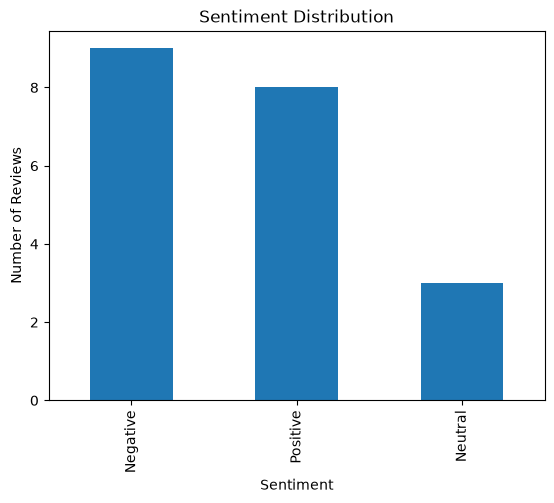

In [8]:
df["Sentiment"].value_counts().plot(kind="bar")

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

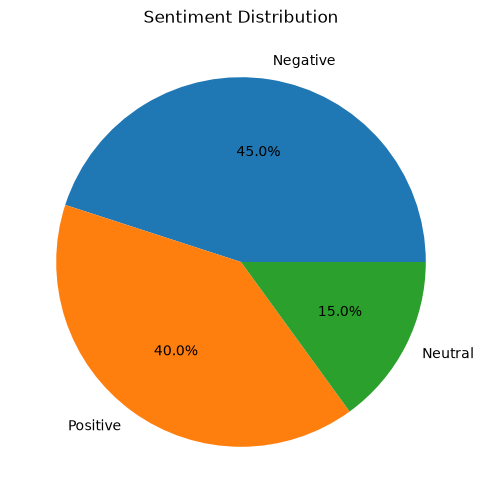

In [9]:
df["Sentiment"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.title("Sentiment Distribution")
plt.ylabel("")

plt.show()

In [10]:
df["Sentiment_Score"] = df["review"].apply(
    lambda x: analyzer.polarity_scores(x)["compound"]
)

df.head()

,review,Sentiment,Sentiment_Score
0,The product is excellent and works perfectly.,Positive,0.8360
1,I am very happy with this purchase.,Positive,0.6115
2,Amazing quality and very useful product.,Positive,0.7902
3,The product exceeded my expectations.,Neutral,0.0000
4,Very good product and fast delivery.,Positive,0.4927


In [11]:
df[df["Sentiment"] == "Positive"]

,review,Sentiment,Sentiment_Score
0,The product is excellent and works perfectly.,Positive,0.8360
1,I am very happy with this purchase.,Positive,0.6115
2,Amazing quality and very useful product.,Positive,0.7902
4,Very good product and fast delivery.,Positive,0.4927
5,I really love this product.,Positive,0.6697
6,The quality is great and worth the money.,Positive,0.7184
7,"Excellent product, I would recommend it.",Positive,0.7351
8,The product is okay.,Positive,0.2263


In [12]:
df[df["Sentiment"] == "Negative"]

,review,Sentiment,Sentiment_Score
10,The product is neither good nor bad.,Negative,-0.5824
12,The quality is poor.,Negative,-0.4767
13,I am disappointed with this product.,Negative,-0.4767
14,The product stopped working after a few days.,Negative,-0.2263
15,Very bad quality.,Negative,-0.5849
16,I regret buying this product.,Negative,-0.4215
17,The product is not worth the money.,Negative,-0.1695
18,The delivery was late and the product was dama...,Negative,-0.4404
19,I did not like this product.,Negative,-0.2755


In [13]:
df[df["Sentiment"] == "Neutral"]

,review,Sentiment,Sentiment_Score
3,The product exceeded my expectations.,Neutral,0.0
9,It is an average product.,Neutral,0.0
11,It works as expected.,Neutral,0.0


In [14]:
df.to_csv("reviews_with_sentiment.csv", index=False)

# Key Findings

1. The review dataset contains 20 customer reviews.

2. The sentiment analysis classified the reviews into Positive, Neutral, and Negative categories.

3. Positive reviews show customer satisfaction with product quality and performance.

4. Negative reviews mainly mention poor quality, product issues, and dissatisfaction.

5. Sentiment visualization helps understand the overall customer feedback distribution.

# Conclusion

Sentiment Analysis was performed on customer review text using Python and VADER.

The reviews were classified into Positive, Neutral, and Negative sentiments.

The results were visualized using bar and pie charts.

This analysis helps understand customer opinions and overall feedback from review data.